In [36]:
# import libraries
import cv2
import tifffile
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import os
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Ellipse
from scipy.spatial.transform import Rotation as R
import matplotlib.colors as mcolors

In [ ]:
# input directory

# circling
input_dir = r'./data/Forward_I'
# skating
# input_dir = r'./data/Forward_II'
# backward
# input_dir = r'./data/Backward'

tif_dir = input_dir + r'/tif'
csv_dir = input_dir + r'/trackmate_csv'
# z-reading parameters
z_reading_path = r'./data_reference/parameters_summary.csv'

# extracted data path
extracted_data_path = input_dir + r'/extracted_data/extracted_data_pd.csv'

# output directory
output_dir = r'./output/Forward_I'
output_dir = output_dir + '/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# given parameters
FPS = 1000/21
# relate pixel size to microns, 110 nm per pixel
pixel_size = 0.11

In [38]:
# load extracted data
data = pd.read_csv(extracted_data_path)

In [39]:
# split data based on tif_name
for tif_name in data.tif_name.unique():
    print(tif_name)
    current_data = data[data.tif_name == tif_name]

I15_entry_0019.nd2 - C=0-2_pair91_1_187


In [40]:
# prepare data
def prepare_data(current_data, FPS, pixel_size):
    prepared_data = pd.DataFrame(columns = ['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z'])
    current_data_small_z = current_data[(current_data.z_center < 1) & (current_data.z_center > -1)]
    major_max = current_data_small_z.ellipse_major.max()
    trackmate_major_max = current_data_small_z.trackmate_ellipse_major.max()
    for frame in current_data.frame.unique():
        current_frame_data = current_data[current_data.frame == frame]
        # --extract data---
        innerback_xy_string = current_frame_data.innerback_xy.values[0].strip("[]")
        innerback_x = float(innerback_xy_string.split()[0])
        innerback_y = float(innerback_xy_string.split()[1])
        innerback_z = 0
        capsule_radius = current_frame_data.innerback_radius_max.values[0]
        center_string = current_frame_data.center.values[0].strip("[]")
        center_x = float(center_string.split()[0])
        center_y = float(center_string.split()[1])
        center_z = float(center_string.split()[2])
        center_left_string = current_frame_data.center_left.values[0].strip("[]")
        center_left_x = float(center_left_string.split()[0])
        center_left_y = float(center_left_string.split()[1])
        center_left_z = float(center_left_string.split()[2])
        center_right_string = current_frame_data.center_right.values[0].strip("[]")
        center_right_x = float(center_right_string.split()[0])
        center_right_y = float(center_right_string.split()[1])
        center_right_z = float(center_right_string.split()[2])
        trackmate_center_xy_string = current_frame_data.trackmate_ellipse_center.values[0].strip("[]")
        trackmate_center_x = float(trackmate_center_xy_string.split()[0])
        trackmate_center_y = float(trackmate_center_xy_string.split()[1])
        trackmate_z = current_frame_data.trackmate_z.values[0] # will overestimate z value since without thresholding
        z_sign = current_frame_data.z_sign.values[0]
        x_init = center_x - innerback_x
        y_init = center_y - innerback_y
        z_init = center_z - innerback_z
        trackmate_x = trackmate_center_x - innerback_x
        trackmate_y = trackmate_center_y - innerback_y
        width = current_frame_data.ellipse_width.values[0]
        height = current_frame_data.ellipse_height.values[0]
        major = max(width, height) * pixel_size
        minor = min(width, height) * pixel_size
        angle_xy_init = current_frame_data.ellipse_angle.values[0]
        trackmate_major = current_frame_data.trackmate_ellipse_major.values[0]
        trackmate_minor = current_frame_data.trackmate_ellipse_minor.values[0] 
        trackmate_theta = np.degrees(current_frame_data.trackmate_ellipse_angle.values[0]) # in degrees

        # --x&y--
        if np.isnan(x_init):
            x = trackmate_x
        else:
            x = x_init
        if np.isnan(y_init):
            y = trackmate_y
        else:
            y = y_init
        # --z--
        if np.isnan(z_init):
            z = 0 # if z_init is nan, set z to 0
        else:
            z = z_init
        
        # --angle_xy--
        if np.isnan(angle_xy_init):
            angle_xy = trackmate_theta
        else:
            angle_xy = angle_xy_init
        # --angle_z--
        if np.isnan(center_left_x) or np.isnan(center_right_x):
            # try to use major axis to estimate angle_z
            try:
                angle_z = np.degrees(np.arccos(np.clip(major/major_max, -1, 1)))
            except:
            # use trackmate to estimate angle_z
                angle_z = np.degrees(np.arccos(np.clip(trackmate_major/trackmate_major_max, -1, 1)))
        else:
            # distance between left and right center
            distance_left_right = np.sqrt((center_left_x - center_right_x)**2 + (center_left_y - center_right_y)**2 + (center_left_z - center_right_z)**2)
            distance_left_right_2D = np.sqrt((center_left_x - center_right_x)**2 + (center_left_y - center_right_y)**2)
            angle_z = np.degrees(np.arccos(np.clip(distance_left_right_2D/distance_left_right, -1, 1)))
        
        # --save--
        new_pd = pd.DataFrame([[frame, x, y, z, capsule_radius, angle_xy, angle_z]], columns = ['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z'])
        prepared_data = pd.concat([prepared_data, new_pd], ignore_index=True)
    return prepared_data

In [41]:
# clean
def clean_data(data):
    cleaned_data = pd.DataFrame(columns = ['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z', 'z_clean'])
    # get dx dy maximum
    dx = np.diff(data.x)
    dy = np.diff(data.y)
    dx_max = np.max(np.abs(dx))
    dy_max = np.max(np.abs(dy))
    dz_max_lim = max(dx_max, dy_max)
    for frame in data.frame.unique():
        if frame == 0:
            new_pd = pd.DataFrame([[frame, data.x.values[0], data.y.values[0], data.z.values[0], data.capsule_radius.values[0], data.angle_xy.values[0], data.angle_z.values[0], False]], columns = ['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z', 'z_clean'])
            cleaned_data = pd.concat([cleaned_data, new_pd], ignore_index=True)
            continue

        current_frame_data = data[data.frame == frame]
        previous_frame_data = data[data.frame == frame - 1]
        current_dz = np.abs(current_frame_data.z.values[0] - previous_frame_data.z.values[0])
        if current_dz <= dz_max_lim:
            z_clean = False
        else:
            z_clean = True     
        new_pd = pd.DataFrame([[frame, current_frame_data.x.values[0], current_frame_data.y.values[0], current_frame_data.z.values[0], current_frame_data.capsule_radius.values[0], current_frame_data.angle_xy.values[0], current_frame_data.angle_z.values[0], z_clean]], columns = ['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z', 'z_clean'])
        cleaned_data = pd.concat([cleaned_data, new_pd], ignore_index=True) 
        
    # replace z with nan if z_clean is True
    for frame in cleaned_data.frame.unique():
        current_frame_data = cleaned_data[cleaned_data.frame == frame]
        if current_frame_data.z_clean.values[0] == True:
            cleaned_data.loc[cleaned_data.frame == frame, 'z'] = np.nan
    return cleaned_data

In [42]:
# smooth data
def smooth_data(data, window_size):
    smoothed_data = pd.DataFrame(columns = ['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z'])
    # sort by frame
    data = data.sort_values(by = 'frame')
    # interpolate missing z
    data['z'] = data['z'].interpolate()
    # rolling mean for x y z 
    data['x_smooth'] = data['x'].rolling(window_size, min_periods = 1).mean()
    data['y_smooth'] = data['y'].rolling(window_size, min_periods = 1).mean()
    data['z_smooth'] = data['z'].rolling(window_size, min_periods = 1).mean()
    # interpolate missing x y z
    data['x_smooth'] = data['x_smooth'].interpolate()
    data['y_smooth'] = data['y_smooth'].interpolate()
    data['z_smooth'] = data['z_smooth'].interpolate()
    # replace
    data['x'] = data['x_smooth']
    data['y'] = data['y_smooth']
    data['z'] = data['z_smooth']
    # save
    smoothed_data = data[['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z']]
    return smoothed_data

In [43]:
# velocity calculation
def velocity(prepared_data, FPS):
    velocity_data = pd.DataFrame(columns = ['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z', 'velocity'])
    for frame in prepared_data.frame.unique():
        current_frame_data = prepared_data[prepared_data.frame == frame]
        x = current_frame_data.x.values[0]
        y = current_frame_data.y.values[0]
        z = current_frame_data.z.values[0]
        capsule_radius = current_frame_data.capsule_radius.values[0]
        angle_xy = current_frame_data.angle_xy.values[0]
        angle_z = current_frame_data.angle_z.values[0]
        if frame == 0:
            velocity = np.nan
        else:
            previous_frame_data = prepared_data[prepared_data.frame == frame - 1]
            dx = x - previous_frame_data.x.values[0]
            dy = y - previous_frame_data.y.values[0]
            dz = z - previous_frame_data.z.values[0]
            velocity = np.sqrt(dx**2 + dy**2 + dz**2) * FPS
        new_pd = pd.DataFrame([[frame, x, y, z, capsule_radius, angle_xy, angle_z, velocity]], columns = ['frame', 'x', 'y', 'z', 'capsule_radius','angle_xy', 'angle_z', 'velocity'])
        velocity_data = pd.concat([velocity_data, new_pd], ignore_index=True)
    return velocity_data

In [44]:
def plot_3D_polish(df, title, cmap=plt.cm.get_cmap('viridis'), continue_figure=False, show_track=True, track_alpha=1, vmin=0, vmax=80,  dot_alpha=0.5, dot_size=10, lin_width=1):
    norm = plt.Normalize(vmin, vmax)
    # plot 3D trajectory
    if continue_figure == False:
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='3d'))  
    else:
        fig, ax = plt.gcf(), plt.gca()
    for i in range(len(df)):
        # color is based on velocity
        color = cmap(norm(df.iloc[i]['velocity']))
        ax.scatter(df.iloc[i]['x'], df.iloc[i]['y'], df.iloc[i]['z'], color=color, alpha=dot_alpha, s=dot_size)
    if show_track == True:
        for i in range(1, len(df)):
            # color is based on velocity
            color = cmap(norm(df.iloc[i]['velocity']))
            ax.plot(df.iloc[i-1:i+1]['x'], df.iloc[i-1:i+1]['y'], df.iloc[i-1:i+1]['z'], '-', alpha=track_alpha, color=color, linewidth=lin_width)
    # set title
    ax.set_title(title)
    # set axis
    ax.set_xlabel('x ($\mu$m)', fontsize=16)
    ax.set_ylabel('y ($\mu$m)', fontsize=16)
    ax.set_zlabel('z ($\mu$m)', fontsize=16)
    # tick font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    # if continue_figure == False:
    #     # set colorbar
    #     sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    #     sm.set_array([])
    #     cbar = fig.colorbar(sm, ax=ax, shrink=0.5)
    #     # colorbar font size
    #     cbar.ax.tick_params(labelsize=14)
    #     cbar.set_label('velocity ($\mu$m/s)', fontsize=20)
    return fig, ax

C:\Users\SSLabPowerfulJunior\AppData\Local\Temp\ipykernel_32184\2802489170.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  def plot_3D_polish(df, title, cmap=plt.cm.get_cmap('viridis'), continue_figure=False, show_track=True, track_alpha=1, vmin=0, vmax=80,  dot_alpha=0.5, dot_size=10, lin_width=1):


In [45]:
prepared_data = prepare_data(current_data, FPS, pixel_size)
cleaned_data = clean_data(prepared_data)
smoothed_data = smooth_data(cleaned_data, 2)
velocity_data = velocity(smoothed_data, FPS)

C:\Users\SSLabPowerfulJunior\AppData\Local\Temp\ipykernel_32184\2972985259.py:85: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


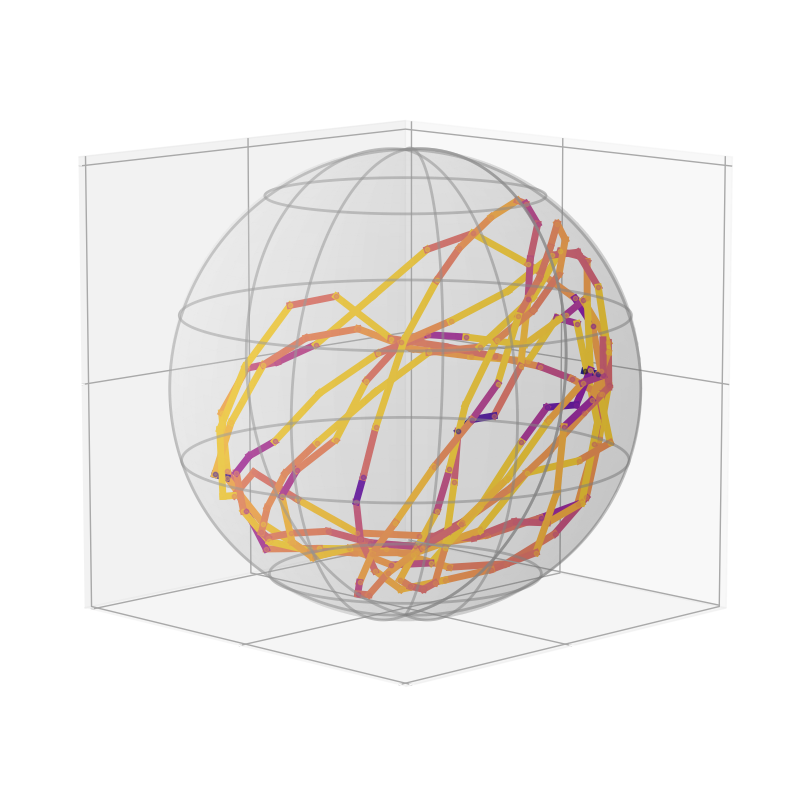

In [46]:
# bug-capsule 3D trajectory (polished version) # for elev = 10, azim = 45, roll = 0
# capsule_radius = velocity_data.capsule_radius.max() + 0.4 # for circling and skating
capsule_radius = 4.3 # for backward
v_min = 20
v_max = 60
lin_width = 5
cmap = plt.cm.plasma
# Modify the colormap: Reduce yellow by truncating the upper end
new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_plasma", cmap(np.linspace(0, 0.9, 256))  # Adjust range (0.9 removes yellow)
)
cmap = new_cmap
# velocity_data_crop = velocity_data[velocity_data.frame < 160]
velocity_data_crop = velocity_data.copy()
fig, ax = plot_3D_polish(velocity_data_crop, '', cmap=cmap, continue_figure=False, vmin=v_min, vmax=v_max, dot_size=10, lin_width=lin_width)
# set axis limit
lim = 4 # for elev = 10, azim = 45, roll = 0

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)


# add 3D capsule as a sphere
# capsule_radius = 5.8/2
origin = [0, 0, 0]
# draw sphere
# 500 points 
u, v = np.mgrid[0:2*np.pi:500j, 0:np.pi:250j]
x = capsule_radius * np.cos(u)*np.sin(v) + origin[0]
y = capsule_radius * np.sin(u)*np.sin(v) + origin[1]
z = capsule_radius * np.cos(v) + origin[2]
# fill sphere
ax.plot_surface(x, y, z, color='#E0E0E0', alpha=0.15)
# outline sphere
ax.plot_wireframe(x, y, z, color='#909090', alpha=0.55, linewidth=2, rstride=75, cstride=50, linestyle='-')

# change view angle
ax.view_init(elev=10, azim=45, roll=0, vertical_axis='z') 
# reverse axis
ax.invert_xaxis()
ax.set_aspect('equal')

# change font size
large_font = 50
small_font = 30
ax.set_xlabel('x', fontsize=large_font, labelpad=15)
ax.set_ylabel('y', fontsize=large_font, labelpad=15)
ax.set_zlabel('z', fontsize=large_font, labelpad=5)
ax.tick_params(axis='both', which='major', labelsize=small_font, pad=5)
# thickness of axis
ax.xaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
ax.yaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)
ax.zaxis._axinfo['grid'].update(color = '#A9A9A9', linestyle = '-', linewidth = 1)


# updates
ax.set_xticks([-4, 0])
ax.set_yticks([-4, 0, 4])
ax.set_zticks([0, 4])


# remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide x-axis line
ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide y-axis line
ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Hide z-axis line
# grid: (3, -lim, -3) to (3, lim, -3)
shift_x = -0.3
shift_y = 0.4
ax.plot([4+shift_x, 4+shift_x], [-lim+shift_y, lim+shift_y], [-4, -4], color='#A9A9A9', alpha=1, linestyle="-", linewidth=1)
# tick colors to gray
# tick_color = '#A9A9A9'
tick_color = 'white'
ax.tick_params(axis='x', colors=tick_color)
ax.tick_params(axis='y', colors=tick_color)
ax.tick_params(axis='z', colors=tick_color)
# remove xyz labels
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')

plt.tight_layout()
# save figure
# plt.savefig(input_dir + os.sep + '3D_trajectory_polished_noxyz.tif', bbox_inches='tight', pad_inches=0, dpi=300)
